# Named entity recognition

In [ ]:
import spacy
from nltk import sent_tokenize

In [ ]:
!python -m spacy download en_core_web_trf

## Load the model

In [ ]:
def load_model():
  nlp = spacy.load("en_core_web_md")
  return nlp

In [ ]:
# Ensure the transformer model is installed in the notebook environment
# %pip install spacy[transformers]
# !python -m spacy download en_core_web_trf

nlp_model = load_model()

## Load dataset

In [ ]:
import sys
import os
import pathlib
folder_path = pathlib.Path().parent.resolve()
sys.path.append(os.path.join(folder_path, '../'))
from utils import load_subtitles_dataset

In [ ]:
dataset_path = "../data/Subtitles"
data = load_subtitles_dataset(dataset_path)
data.head()

In [ ]:
sample_script = data.iloc[0]['script']
sample_script

In [ ]:
sentences = sent_tokenize(sample_script)
print(f"Number of sentences: {len(sentences)}")
print(sentences[60:90])

In [ ]:
sentences = ".".join(sentences)
sentences

## Running the model

In [ ]:
doc = nlp_model(sentences)
doc.ents

In [ ]:
for entity in doc.ents:
  print(f"Entity: {entity.text}, Label: {entity.label_}")

In [ ]:
def get_ners_inference(script):
  script_sentences = sent_tokenize(script)

  ner_output = []

  for sentence in script_sentences:
    doc = nlp_model(sentence)
    ners = set()
    for entity in doc.ents:
      if entity.label_ =="PERSON":
        full_name = entity.text
        first_name = entity.text.split(" ")[0]
        first_name = first_name.strip()
        ners.add(first_name)
    ner_output.append(ners)

  return ner_output

In [ ]:
data = data.head(10)
data

In [ ]:
data['ners'] = data['script'].apply(get_ners_inference)

In [20]:
data

,episode,script,ners
0,1,"A long time ago, a powerful demon fox appeared...","[{}, {}, {}, {}, {}, {}, {Ninja}, {Naruto}, {}..."
1,2,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {..."
2,3,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {Sasuke, Sakura}, {}, {Konohamaru..."
3,4,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {Naruto}, {}, {}, {Iruka}, {}, {N..."
4,5,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {Jutsu}, {}, {}, {Ninja}, {}, {}, {},..."
5,6,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {Sakura}, {Naruto}, {}, {Naruto},..."
6,7,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {..."
7,8,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {}, {}, {Jonin}, {}, {Sasuke}, {}..."
8,9,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {}, {..."
9,12,"C'mon!\n Running like a fugitive,\n Being chas...","[{}, {}, {}, {}, {Zabuza}, {}, {}, {}, {Naruto..."


## Charcter network

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network

In [23]:
def generate_character_network(df):

  windows=10
  entity_relationship = []

  for row in df['ners']:
    previous_entities_in_window = []

    for sentence in row:
      previous_entities_in_window.append(list(sentence))
      previous_entities_in_window = previous_entities_in_window[-windows:]

      # Flatten 2D List into 1D List
      previous_entities_flattened = sum(previous_entities_in_window, [])

      for entity in sentence:
        for entity_in_window in previous_entities_flattened:
          if entity != entity_in_window:
            entity_relationship.append(sorted([entity, entity_in_window]))
  
  relationship_df = pd.DataFrame({'value': entity_relationship})
  relationship_df['source'] = relationship_df['value'].apply(lambda x: x[0])
  relationship_df['target'] = relationship_df['value'].apply(lambda x: x[1])
  relationship_df = relationship_df.groupby(['source', 'target']).count().reset_index()
  relationship_df = relationship_df.sort_values('value', ascending=False)

  return relationship_df

In [24]:
relationship_df = generate_character_network(data)
relationship_df

,source,target,value
161,Naruto,Sasuke,87
185,Sakura,Sasuke,53
84,Iruka,Naruto,45
160,Naruto,Sakura,33
157,Naruto,Ninja,29
...,...,...,...
204,Sharingan,Ushi,1
207,Shikamaru,Shino,1
208,Tazuna,Zabuza,1
209,The,Zabuza,1


In [25]:
relationship_df = relationship_df.sort_values('value', ascending=False)
relationship_df = relationship_df.head(200)

In [27]:
G = nx.from_pandas_edgelist(
  relationship_df, 
  source='source', 
  target='target', 
  edge_attr='value',
  create_using=nx.Graph()
)

net = Network(notebook=True, width="1000px", height="700px", bgcolor="#222222", font_color="white", cdn_resources="remote")
node_degree = dict(G.degree)

nx.set_node_attributes(G, node_degree, 'size')
net.from_nx(G)
net.show("naruto.html")

naruto.html


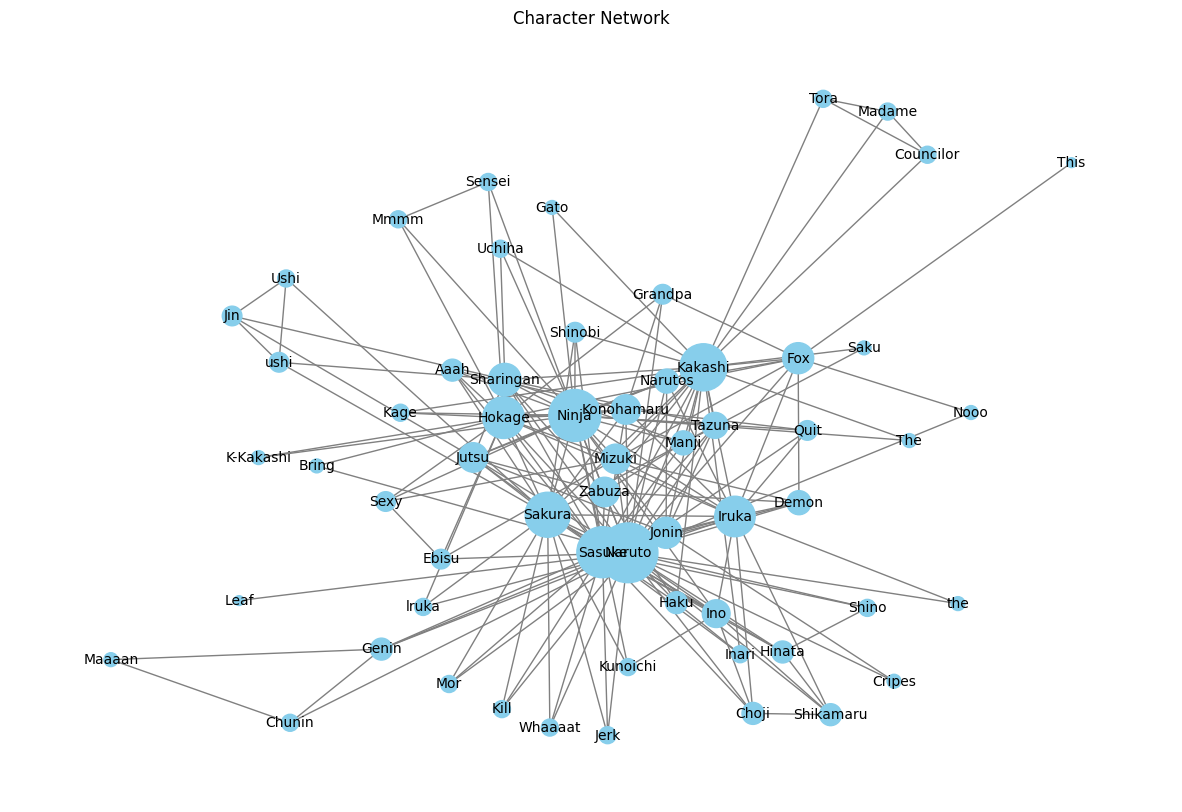

In [28]:
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)
node_sizes = [node_degree.get(node, 1) * 50 for node in G.nodes()]
nx.draw_networkx(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=node_sizes, font_size=10)
plt.title("Character Network")
plt.axis('off')
plt.savefig("character_network.png", bbox_inches='tight')
plt.show()